# Incrementality Measurement & MMM Attribution Validation with Google Meridian

This notebook validates whether a Bayesian Marketing Mix Model ([Google Meridian](https://github.com/google/meridian)) can recover **known ground-truth channel ROI** from a 104-week synthetic dataset (Meta, Google, TikTok).

The dataset is loaded directly from the [project repository](https://github.com/laurakeita/meridian-mmm-attribution-validation) — no Google Drive setup is required. See the README for the full write-up, key results, and business context.

> **Runtime note:** MCMC sampling (Section 5) takes several minutes — a Colab GPU runtime is recommended.


## 1. Setup

Install Meridian and import dependencies.

In [29]:
!pip install -q git+https://github.com/google/meridian.git altair


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
import IPython

from meridian import constants
from meridian.data import load
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
from meridian.analysis import formatter

# Check available runtime resources
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.experimental.list_physical_devices('CPU')))


Your runtime has 13.6 gigabytes of available RAM

Num GPUs Available:  1
Num CPUs Available:  1


## 2. Data Loading & Audit

The dataset is loaded straight from GitHub. Media spend, impression, and KPI columns are **detected dynamically** from column names, so the framework is portable across datasets.

The audit checks three identifiability risks before any modelling:
1. **Spend share** — channels with very small spend are harder to measure.
2. **Correlation with revenue** — a first look at signal strength.
3. **Multicollinearity (VIF)** — channels that move together are hard for any attribution model to separate. This is the core identifiability risk this project investigates.


In [31]:
# Load the synthetic dataset directly from the GitHub repository
DATA_URL = 'https://raw.githubusercontent.com/laurakeita/meridian-mmm-attribution-validation/main/data/synthetic_mmm_data.csv'
data = pd.read_csv(DATA_URL)
print(data.columns)

# Identify media spend columns dynamically (keywords: spend / cost / budget)
media = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in ['spend', 'cost', 'budget'])
]

# Exclude media channels with zero total spend
media = [col for col in media if data[col].sum() > 0]
print("Selected Media Channels:", media)

# Identify impression columns dynamically
impressions = [
    col for col in data.columns
    if 'impression' in col.lower()
]
print("Impressions List:", impressions)

# Parse dates (yyyy/mm/dd) and drop rows that fail to parse
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d', errors='coerce')
data = data.dropna(subset=['date'])

# Identify the KPI (revenue) column dynamically
output = [col for col in data.columns if 'revenue' in col.lower()]
print("KPI column:", output)

display(data.head())


Index(['date', 'Revenue', 'Offline Discount', 'Holiday', 'Trend', 'Meta spend',
       'Google spend', 'TikTok spend', 'Meta impression', 'Google impression',
       'TikTok impression'],
      dtype='object')
Selected Media Channels: ['Meta spend', 'Google spend', 'TikTok spend']
Impressions List: ['Meta impression', 'Google impression', 'TikTok impression']
KPI column: ['Revenue']


,date,Revenue,Offline Discount,Holiday,Trend,Meta spend,Google spend,TikTok spend,Meta impression,Google impression,TikTok impression
0,2023-01-01,77393.32,0,1,0,3680.70,10573.51,2565.75,345693,778274,260787
1,2023-01-08,73200.02,0,1,1,2113.26,4941.53,1190.52,243358,346154,129874
2,2023-01-15,80416.43,0,0,2,5319.12,5451.20,1774.33,544435,492993,240475
3,2023-01-22,79735.14,0,0,3,4553.68,8153.25,5294.12,420110,631738,587826
4,2023-01-29,90203.78,0,0,4,8669.87,7493.24,2050.74,814837,594525,248965


******** Spend Share Analysis ********
  Media_Channel  Spend_Share
0    Meta spend     0.425028
1  Google spend     0.397730
2  TikTok spend     0.177242


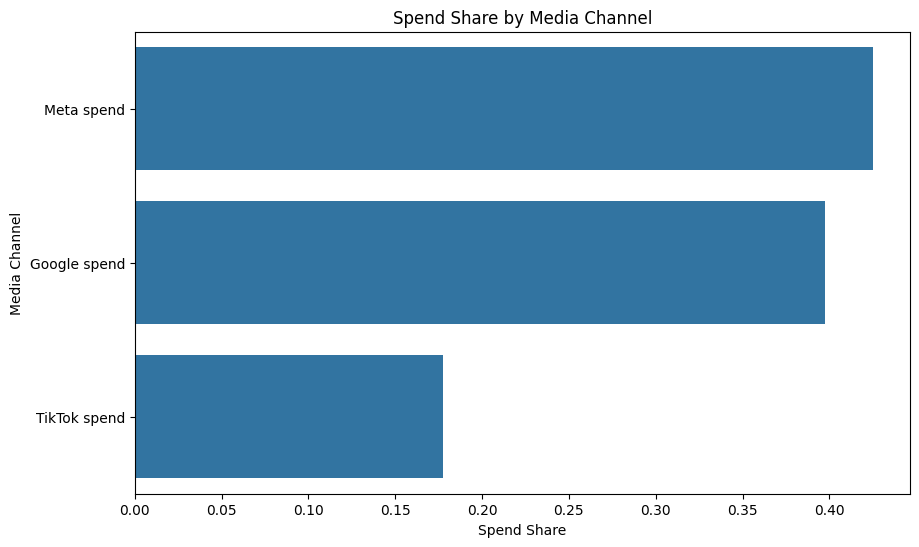


******** Correlation Analysis ********
Using revenue column: Revenue
Correlation of inputs with Revenue:
Offline Discount     0.434932
Google impression    0.420054
Google spend         0.416130
Trend                0.293735
Holiday              0.159645
Meta impression      0.139795
Meta spend           0.127197
TikTok spend         0.098446
TikTok impression    0.070025
Name: Revenue, dtype: float64


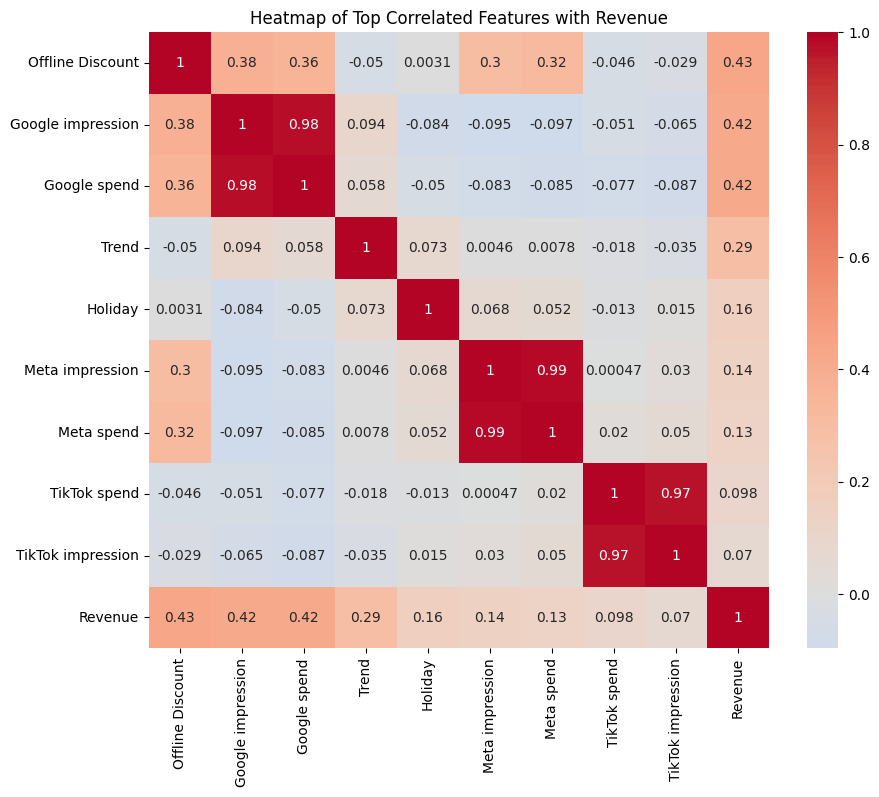


******** Multicollinearity Analysis ********
        Feature       VIF
1  Google spend  1.013087
0    Meta spend  1.007416
2  TikTok spend  1.006185

******** Variables with Less Than 15 Records ********
All variables have at least 15 records.


In [32]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----------------------------
# 1. Spend Share Analysis
# ----------------------------
print("******** Spend Share Analysis ********")
if media:
    # Calculate total spend across all identified media channels.
    total_media_spend = data[media].sum().sum()
    # Compute spend share for each media channel.
    spend_share = data[media].sum() / total_media_spend
    spend_share_df = spend_share.reset_index()
    spend_share_df.columns = ['Media_Channel', 'Spend_Share']
    print(spend_share_df)

    # Plot a bar chart of spend share.
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Spend_Share', y='Media_Channel',
                data=spend_share_df.sort_values(by='Spend_Share', ascending=False))
    plt.title("Spend Share by Media Channel")
    plt.xlabel("Spend Share")
    plt.ylabel("Media Channel")
    plt.show()
else:
    print("No media channels available for spend share analysis.")


# ----------------------------
# 2. Correlation Analysis between Inputs and Output (ecommerce_revenue)
# ----------------------------
print("\n******** Correlation Analysis ********")
revenue_col = output[0] if output and output[0] in data.columns else 'ecommerce_revenue'
print("Using revenue column:", revenue_col)

numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

if revenue_col in corr_matrix.columns:
    corr_with_rev = corr_matrix[revenue_col].drop(labels=[revenue_col]).sort_values(ascending=False)
    print("Correlation of inputs with {}:".format(revenue_col))
    print(corr_with_rev)

    # Identify top 10 features most correlated (by absolute value) with the revenue.
    top_features = corr_with_rev.abs().sort_values(ascending=False).head(10).index.tolist() + [revenue_col]

    # Plot a heatmap displaying correlations among these top features.
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_data[top_features].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title("Heatmap of Top Correlated Features with {}".format(revenue_col))
    plt.show()
else:
    print("Revenue column not found in the correlation matrix.")


# ----------------------------
# 3. Multicollinearity Analysis (Variance Inflation Factor)
# ----------------------------
print("\n******** Multicollinearity Analysis ********")
from statsmodels.tools.tools import add_constant

# VIF is computed across the media spend channels, with an intercept added
# (without a constant term, VIF values are inflated and unreliable).
vif_features = data[media]
X_vif = add_constant(vif_features)
vif_df = pd.DataFrame({
    "Feature": vif_features.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1)
            for i in range(len(vif_features.columns))]
})
print(vif_df.sort_values(by="VIF", ascending=False))


# ----------------------------
# 4. Check for Variables with Less Than 15 Records
# ----------------------------
print("\n******** Variables with Less Than 15 Records ********")
low_record_columns = {col: data[col].count() for col in data.columns if data[col].count() < 15}
if low_record_columns:
    for col, cnt in low_record_columns.items():
        print(f"Column '{col}' has only {cnt} recorded non-null entries.")
else:
    print("All variables have at least 15 records.")


## 3. Meridian Data Preparation

Map the detected spend / impression columns to simplified channel names and build Meridian's `InputData`. Control variables are only passed to the model if they exist in the loaded data.


In [33]:
def create_channel_mappings(media, impressions):
    """
    Generate mapping dictionaries from spend / impression column names
    to simplified channel names (e.g. 'Meta spend' -> 'Meta').

    Parameters:
        media (list of str): Column names holding spend/cost data.
        impressions (list of str): Column names holding impressions data.

    Returns:
        tuple: (spend_column -> channel_name, impression_column -> channel_name)
    """
    correct_media_spend_to_channel = {}
    for col in media:
        if col.lower().endswith("spend"):
            channel_name = col[:-len("spend")].strip()
        else:
            channel_name = col
        correct_media_spend_to_channel[col] = channel_name

    correct_media_to_channel = {}
    for col in impressions:
        if col.lower().endswith("impression"):
            channel_name = col[:-len("impression")].strip()
        else:
            channel_name = col
        correct_media_to_channel[col] = channel_name

    return correct_media_spend_to_channel, correct_media_to_channel

cost_mapping, impressions_mapping = create_channel_mappings(media, impressions)

print("Cost Mapping:", cost_mapping)
print("Impressions Mapping:", impressions_mapping)


Cost Mapping: {'Meta spend': 'Meta', 'Google spend': 'Google', 'TikTok spend': 'TikTok'}
Impressions Mapping: {'Meta impression': 'Meta', 'Google impression': 'Google', 'TikTok impression': 'TikTok'}


In [34]:
print(data.columns)

# Controls are only passed to Meridian if they exist in the loaded data
control_candidates = ['Offline Discount']
controls = [c for c in control_candidates if c in data.columns]
print("Controls used:", controls)

coord_to_columns = load.CoordToColumns(
    time='date',
    kpi=output[0],
    controls=controls if controls else None,
    media=impressions,   # impression columns (media execution metric)
    media_spend=media,   # spend columns
)

loader = load.DataFrameDataLoader(
    df=data,
    kpi_type='revenue',
    coord_to_columns=coord_to_columns,
    media_spend_to_channel=cost_mapping,
    media_to_channel=impressions_mapping,
)
data_meridian = loader.load()


Index(['date', 'Revenue', 'Offline Discount', 'Holiday', 'Trend', 'Meta spend',
       'Google spend', 'TikTok spend', 'Meta impression', 'Google impression',
       'TikTok impression'],
      dtype='object')
Controls used: ['Offline Discount']


/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:588: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [35]:
data_meridian.as_dataset()

<xarray.Dataset> Size: 31kB
Dimensions:           (time: 104, geo: 1, control_variable: 1,
                       media_channel: 3, media_time: 104)
Coordinates:
  * time              (time) <U28 12kB '2023-01-01' ... '2024-12-22'
  * geo               (geo) <U12 48B 'national_geo'
  * control_variable  (control_variable) object 8B 'Offline Discount'
  * media_channel     (media_channel) object 24B 'Meta' 'Google' 'TikTok'
  * media_time        (media_time) <U28 12kB '2023-01-01' ... '2024-12-22'
Data variables:
    kpi               (geo, time) float64 832B 7.739e+04 7.32e+04 ... 1.032e+05
    population        (geo) float64 8B 1.0
    controls          (geo, time, control_variable) int64 832B 0 0 0 0 ... 0 0 0
    revenue_per_kpi   (geo, time) float64 832B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    media             (geo, media_time, media_channel) int64 2kB 345693 ... 7...
    media_spend       (geo, time, media_channel) float64 2kB 3.681e+03 ... 637.8

## 4. Priors & Model Specification

The channel ROI prior is a **log-normal distribution with mean 2 and standard deviation 1.5**, reparameterised into log-space (`mu_log`, `sigma_log`) as required by TensorFlow Probability. This encodes a weakly informative belief that media ROI is positive and centred around 2x.


In [36]:
# Function to translate the media ROI prior into a log-normal distribution
# usable by the model priors

def estimate_lognormal_dist(mean, std):
    """
    Reparameterizes the LogNormal distribution in terms of its mean and std.
    Returns mu_log and std_log which can be used to define a LogNormal.
    """
    mu_log = np.log(mean) - 0.5 * np.log((std/mean)**2 + 1)
    std_log = np.sqrt(np.log((std/mean)**2 + 1))
    return mu_log, std_log

roi_mu = 2
roi_sigma = 1.5

roi_mu_log, roi_sigma_log = estimate_lognormal_dist(roi_mu, roi_sigma)
print(roi_mu_log, roi_sigma_log)


0.4700036292457355 0.6680472308365776


In [37]:
# Prior Distribution
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
       loc=np.float32(roi_mu_log),
       scale=np.float32(roi_sigma_log),
       name=constants.ROI_M)
)

# Build Meridian Model
# Initializing ModelSpec directly with parameters from the old create_model_spec call and the prior
# Mapping n_lags and adstock_max_lag_weight to max_lag (assuming this is the correct parameter name)
model_spec = spec.ModelSpec(
    prior=prior,
    max_lag=7, # Assuming adstock_max_lag_weight maps to max_lag
)

# Initialize the model for posterior sampling
mmm = model.Meridian(input_data=data_meridian, model_spec=model_spec)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


## 5. MCMC Sampling & Convergence Diagnostics

Posterior sampling runs **5 chains x 2,000 kept draws** (1,000 adaptation + 1,000 burn-in). Convergence is verified with trace plots and R-hat (target: all parameters <= 1.1).


In [10]:
mmm.sample_prior(100)

mmm.sample_posterior(
    n_chains=5,
    n_adapt=1000,
    n_burnin=1000,
    n_keep=2000,
)

model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.predictive_accuracy_table()


/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1365: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1365: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1365: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1365: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_om has been automatically se

,metric,geo_granularity,value
0,R_Squared,national,0.297335
1,MAPE,national,0.087929
2,wMAPE,national,0.086605


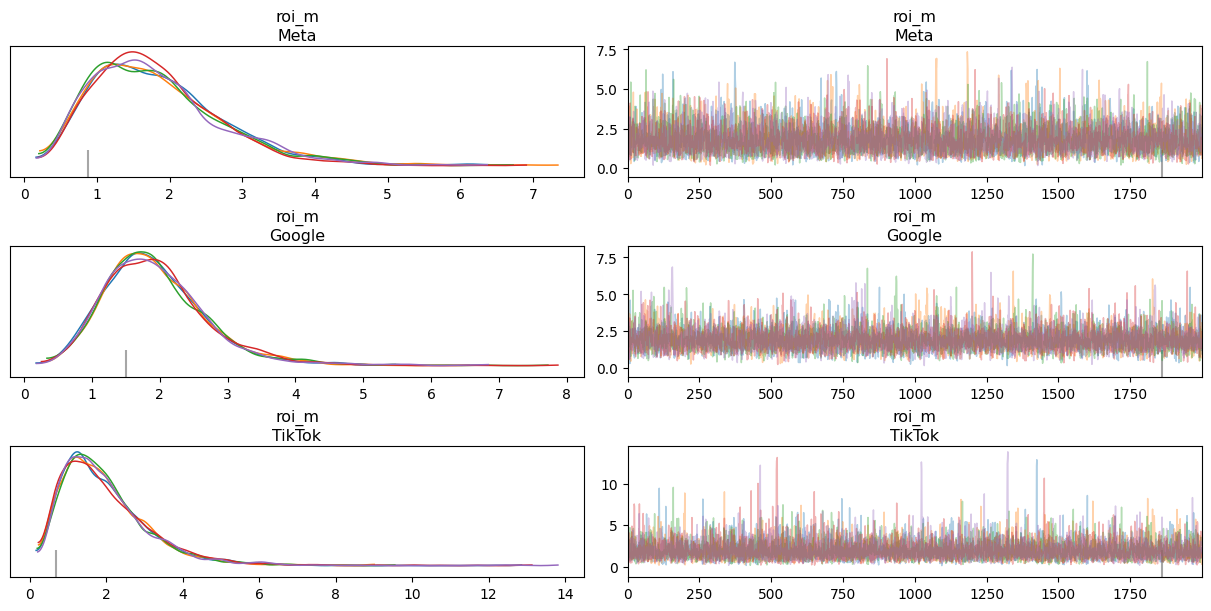

In [11]:
parameters_to_plot=["roi_m"]
for params in parameters_to_plot:
  az.plot_trace(
      mmm.inference_data,
      var_names=params,
      compact=False,
      backend_kwargs={"constrained_layout": True},
  )


In [12]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

## 6. Model Fit & Summary Report

Generate Meridian's two-page HTML summary report (model fit, ROI, response curves) and plot expected vs actual revenue. Report dates are derived from the data rather than hardcoded.


In [13]:
mmm_summarizer = summarizer.Summarizer(mmm)

filepath = '/content'  # saved to local Colab storage; download from the Files sidebar
start_date = data["date"].min().strftime("%Y-%m-%d")
end_date = data["date"].max().strftime("%Y-%m-%d")
mmm_summarizer.output_model_results_summary('summary_output.html', filepath, start_date, end_date)

# Preview the 2-pager
IPython.display.HTML(filename='/content/summary_output.html')


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:2395: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:302: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(


Dataset,R-squared,MAPE,wMAPE
All Data,0.30,9%,9%


In [14]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

In [15]:
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:302: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,Meta,prior,"60,325,728",44%,"$629,752",43%,$10,"$1,178,144 ($269,756, $2,416,086)","10% (2%, 20%)","1.9 (0.4, 3.8)","0.02 (0.00, 0.04)","0.7 (0.2, 1.8)","$0.7 ($0.3, $2.3)"
1,Meta,posterior,"60,325,728",44%,"$629,752",43%,$10,"$1,158,238 ($414,305, $2,215,195)","13% (5%, 25%)","1.8 (0.7, 3.5)","0.02 (0.01, 0.04)","0.8 (0.2, 1.6)","$0.6 ($0.3, $1.5)"
2,Google,prior,"46,758,488",34%,"$589,306",40%,$13,"$1,230,313 ($405,092, $2,745,733)","10% (3%, 23%)","2.1 (0.7, 4.7)","0.03 (0.01, 0.06)","1.0 (0.2, 2.3)","$0.6 ($0.2, $1.5)"
3,Google,posterior,"46,758,488",34%,"$589,306",40%,$13,"$1,143,208 ($517,674, $1,963,745)","13% (6%, 22%)","1.9 (0.9, 3.3)","0.02 (0.01, 0.04)","1.0 (0.4, 1.6)","$0.5 ($0.3, $1.1)"
4,TikTok,prior,"31,227,244",23%,"$262,616",18%,$8,"$466,150 ($148,401, $1,110,331)","4% (1%, 9%)","1.8 (0.6, 4.2)","0.01 (0.00, 0.04)","0.8 (0.1, 2.0)","$0.7 ($0.2, $1.8)"
5,TikTok,posterior,"31,227,244",23%,"$262,616",18%,$8,"$522,981 ($164,538, $1,093,763)","6% (2%, 12%)","2.0 (0.6, 4.2)","0.02 (0.01, 0.04)","0.9 (0.2, 1.9)","$0.6 ($0.2, $1.6)"
6,All Channels,prior,"138,311,456",100%,"$1,481,673",100%,$11,"$2,874,607 ($1,442,161, $5,569,867)","24% (12%, 46%)","1.9 (1.0, 3.8)","nan (nan, nan)","nan (nan, nan)","$0.6 ($0.3, $1.0)"
7,All Channels,posterior,"138,311,456",100%,"$1,481,673",100%,$11,"$2,824,426 ($1,667,638, $4,306,382)","32% (19%, 49%)","1.9 (1.1, 2.9)","nan (nan, nan)","nan (nan, nan)","$0.5 ($0.3, $0.9)"


## 7. Attribution Validation vs Ground Truth

This is the core of the project: comparing Meridian's **estimated posterior ROI** against the **ground-truth ROI used to generate the synthetic data**.

> Ground-truth ROI was defined for **Meta and Google** during data generation, so validation covers those two channels; TikTok is reported descriptively only.

A low prediction error (MAPE) does **not** guarantee accurate attribution — this section quantifies the gap.


In [16]:
import re

# ==========================================
# Attribution Validation
# ==========================================

print("\n" + "="*50)
print("ATTRIBUTION VALIDATION")
print("="*50)

# Ground-truth ROI from the synthetic data-generating process.
# (Defined for Meta and Google only; TikTok has no ground-truth value.)
true_roi = {
    "Meta": 2.07,
    "Google": 3.00
}

# Meridian estimated ROI
summary_df = media_summary.summary_table()

print("\nEstimated ROI:")
print(summary_df)

roi_validation_results = []

for channel in true_roi.keys():

    try:
        # Filter for posterior distribution for the current channel
        channel_posterior_summary = summary_df[
            (summary_df["distribution"] == "posterior") &
            (summary_df["channel"].str.contains(channel, case=False, na=False))
        ]

        if not channel_posterior_summary.empty:
            # Extract the point estimate from the formatted "mean (lo, hi)" string
            roi_str = str(channel_posterior_summary["roi"].iloc[0])
            estimated_roi = float(re.search(r"[-+]?\d*\.?\d+", roi_str).group())

            error_pct = (
                abs(estimated_roi - true_roi[channel])
                / true_roi[channel]
            ) * 100

            roi_validation_results.append({
                "channel": channel,
                "true_roi": true_roi[channel],
                "estimated_roi": estimated_roi,
                "recovery_error_pct": round(error_pct,2)
            })
        else:
            print(f"Could not find posterior ROI for {channel}")

    except Exception as e:
        print(f"An error occurred while processing ROI for {channel}: {e}")

validation_df = pd.DataFrame(
    roi_validation_results
)

print("\nROI Recovery Validation")
print(validation_df)

avg_error = validation_df[
    "recovery_error_pct"
].mean()

print(
    f"\nAverage ROI Recovery Error: {avg_error:.2f}%"
)


ATTRIBUTION VALIDATION

Estimated ROI:
        channel distribution  impressions % impressions       spend % spend  \
0          Meta        prior   60,325,728           44%    $629,752     43%   
1          Meta    posterior   60,325,728           44%    $629,752     43%   
2        Google        prior   46,758,488           34%    $589,306     40%   
3        Google    posterior   46,758,488           34%    $589,306     40%   
4        TikTok        prior   31,227,244           23%    $262,616     18%   
5        TikTok    posterior   31,227,244           23%    $262,616     18%   
6  All Channels        prior  138,311,456          100%  $1,481,673    100%   
7  All Channels    posterior  138,311,456          100%  $1,481,673    100%   

   cpm                  incremental outcome  % contribution             roi  \
0  $10    $1,178,144 ($269,756, $2,416,086)   10% (2%, 20%)  1.9 (0.4, 3.8)   
1  $10    $1,158,238 ($414,305, $2,215,195)   13% (5%, 25%)  1.8 (0.7, 3.5)   
2  $13    $

/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


## 8. Media Effect Visualisations

Contribution waterfall and pie, spend vs contribution, ROI comparisons, response curves, and adstock decay.


In [17]:
media_summary.plot_contribution_waterfall_chart()


alt.LayerChart(...)

In [18]:
media_summary.plot_contribution_pie_chart()


alt.LayerChart(...)

In [19]:
media_summary.plot_spend_vs_contribution()


alt.FacetChart(...)

In [20]:
media_summary.plot_roi_bar_chart()


alt.LayerChart(...)

In [21]:
media_summary.plot_roi_vs_effectiveness()


alt.Chart(...)

In [22]:
media_summary.plot_roi_vs_mroi()


alt.Chart(...)

In [23]:
media_effects = visualizer.MediaEffects(mmm)
media_effects.plot_response_curves()

alt.FacetChart(...)

In [24]:
media_effects.plot_adstock_decay()


alt.FacetChart(...)

## 9. Budget Optimisation (Fixed Budget, +/-30% Constraints)

Reallocates the historical budget to maximise incremental revenue. The optimisation period is derived from the data (`date.min()` / `date.max()`), and each channel's spend is constrained to **+/-30% of its historical level** (Meridian's fixed-budget scenario).


In [25]:
# Optimisation period derived from the data rather than hardcoded
start_date_opt = data['date'].min().strftime('%Y-%m-%d')
end_date_opt = data['date'].max().strftime('%Y-%m-%d')

current_spend = data[media].sum()
print("Current spend by channel in optimisation period:")
print(current_spend)
print(f"\nTotal budget: {current_spend.sum():,.0f}")

budget_optimizer = optimizer.BudgetOptimizer(mmm)

# Fixed-budget scenario: reallocate the existing budget with each channel
# constrained to +/-30% of its historical spend
optimization_results = budget_optimizer.optimize(
    start_date=start_date_opt,
    end_date=end_date_opt,
    spend_constraint_lower=0.3,  # each channel may decrease by at most 30%
    spend_constraint_upper=0.3,  # each channel may increase by at most 30%
)


Current spend by channel in optimisation period:
Meta spend      629752.39
Google spend    589305.55
TikTok spend    262615.48
dtype: float64

Total budget: 1,481,673


In [26]:
optimization_results.nonoptimized_data

<xarray.Dataset> Size: 648B
Dimensions:              (channel: 3, metric: 4)
Coordinates:
  * channel              (channel) object 24B 'Meta' 'Google' 'TikTok'
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 24B 6.3e+05 5.89e+05 2.63e+05
    pct_of_spend         (channel) float64 24B 0.4251 0.3974 0.1775
    incremental_outcome  (channel, metric) float64 96B 1.158e+06 ... 1.094e+06
    effectiveness        (channel, metric) float64 96B 0.0192 ... 0.03499
    roi                  (channel, metric) float64 96B 1.839 1.693 ... 4.16
    mroi                 (channel, metric) float64 96B 0.7938 0.7345 ... 1.85
    cpik                 (channel, metric) float64 96B 0.7104 0.5908 ... 1.597
Attributes:
    start_date:                 2023-01-01
    end_date:                   2024-12-22
    budget:                     1482000.0
    profit:                     1342666.0
    total_incremental_outcome:  2824666.0
    total_roi:                  1.9059825
    total_cpik:                 0.5689423084259033
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      True

In [27]:
optimization_results.optimized_data


<xarray.Dataset> Size: 648B
Dimensions:              (channel: 3, metric: 4)
Coordinates:
  * channel              (channel) object 24B 'Meta' 'Google' 'TikTok'
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 24B 5.73e+05 6.51e+05 2.58e+05
    pct_of_spend         (channel) float64 24B 0.3866 0.4393 0.1741
    incremental_outcome  (channel, metric) float64 96B 1.111e+06 ... 1.086e+06
    effectiveness        (channel, metric) float64 96B 0.02024 ... 0.0354
    roi                  (channel, metric) float64 96B 1.938 1.778 ... 4.21
    mroi                 (channel, metric) float64 96B 0.8733 0.8109 ... 1.882
    cpik                 (channel, metric) float64 96B 0.6755 0.5624 ... 1.58
Attributes:
    start_date:                 2023-01-01
    end_date:                   2024-12-22
    budget:                     1482000.0
    profit:                     1347543.2
    total_incremental_outcome:  2829543.2
    total_roi:                  1.9092735
    total_cpik:                 0.5673092007637024
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      True
    fixed_budget:               True

In [28]:
filepath = '/content'  # saved to local Colab storage; download from the Files sidebar
optimization_results.output_optimization_summary('optimization_output.html', filepath)
IPython.display.HTML(filename='/content/optimization_output.html')


Channel,Non-optimized spend,Optimized spend
Google,40%,44%
Meta,43%,39%
TikTok,18%,17%
